<a href="https://colab.research.google.com/github/lucasluanvidal40-max/Linguagem-de-Programa-o/blob/main/Atividade_U3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Resumo de Vendas por Categoria ---
  categoria  valor_venda
Eletrônicos       6100.0
     Roupas       1800.0
     Livros        900.0




/tmp/ipykernel_2453/3566848474.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categoria', y='valor_venda', data=vendas_por_categoria, palette='viridis')


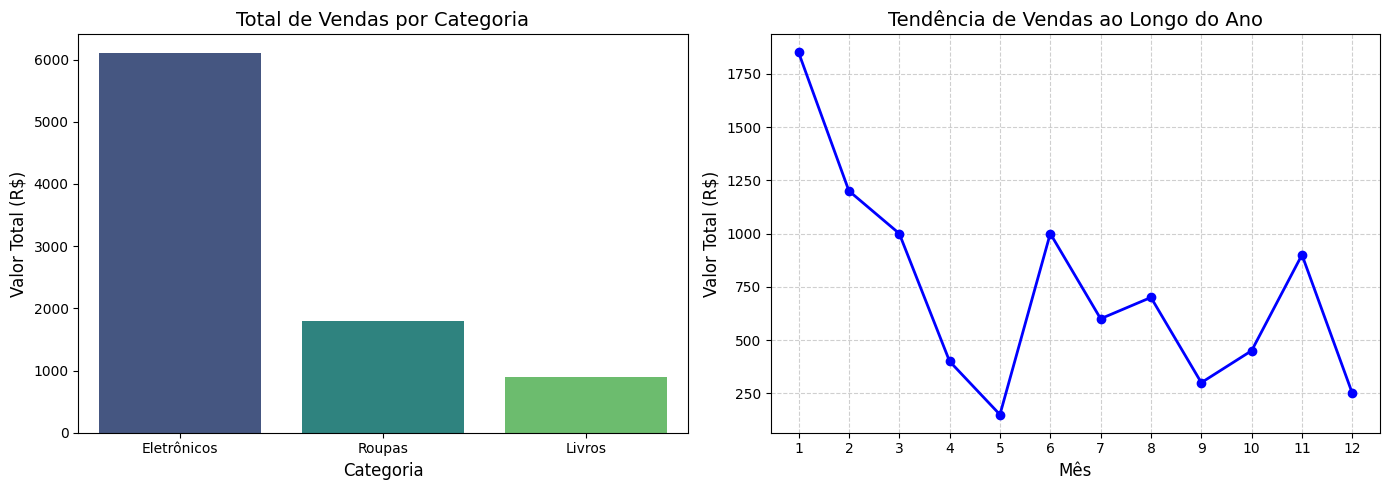


--- Insights e Conclusão ---
1. Liderança de Receita: A categoria 'Eletrônicos' é de longe a mais lucrativa, representando a maior fatia do faturamento (R$ 6.100,00).
2. Oportunidade de Crescimento: As categorias 'Roupas' (R$ 1.800,00) e 'Livros' (R$ 900,00) têm desempenho inferior. Sugere-se a criação de promoções em conjunto (cross-selling) com os eletrônicos para impulsionar essas vendas.
3. Sazonalidade: Houve um pico expressivo de vendas em janeiro (R$ 1.850,00), possivelmente devido a liquidações de início de ano, com quedas significativas em maio (R$ 150,00) e dezembro (R$ 250,00). É necessário revisar a estratégia de marketing de final de ano.


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conexao = sqlite3.connect('dados_vendas.db')
cursor = conexao.cursor()

cursor.execute('DROP TABLE IF EXISTS vendas1')

cursor.execute('''
CREATE TABLE vendas1 (
    id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
    data_venda DATE,
    produto TEXT,
    categoria TEXT,
    valor_venda REAL
)
''')

cursor.execute('''
INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda) VALUES
('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
('2023-01-05', 'Produto B', 'Roupas', 350.00),
('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
('2023-03-15', 'Produto D', 'Livros', 200.00),
('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
('2023-04-02', 'Produto F', 'Roupas', 400.00),
('2023-05-05', 'Produto G', 'Livros', 150.00),
('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
('2023-07-20', 'Produto I', 'Roupas', 600.00),
('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
('2023-09-30', 'Produto K', 'Livros', 300.00),
('2023-10-05', 'Produto L', 'Roupas', 450.00),
('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
('2023-12-20', 'Produto N', 'Livros', 250.00);
''')
conexao.commit()

df_vendas = pd.read_sql_query("SELECT * FROM vendas1", conexao)

df_vendas['data_venda'] = pd.to_datetime(df_vendas['data_venda'])
df_vendas['mes'] = df_vendas['data_venda'].dt.month

vendas_por_categoria = df_vendas.groupby('categoria')['valor_venda'].sum().reset_index()
vendas_por_categoria = vendas_por_categoria.sort_values(by='valor_venda', ascending=False)

vendas_por_mes = df_vendas.groupby('mes')['valor_venda'].sum().reset_index()

print("--- Resumo de Vendas por Categoria ---")
print(vendas_por_categoria.to_string(index=False))
print("\n")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='categoria', y='valor_venda', data=vendas_por_categoria, palette='viridis')
plt.title('Total de Vendas por Categoria', fontsize=14)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Valor Total (R$)', fontsize=12)

plt.subplot(1, 2, 2)
plt.plot(vendas_por_mes['mes'], vendas_por_mes['valor_venda'], marker='o', color='b', linestyle='-', linewidth=2)
plt.title('Tendência de Vendas ao Longo do Ano', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Valor Total (R$)', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

conexao.close()

print("\n--- Insights e Conclusão ---")
print("1. Liderança de Receita: A categoria 'Eletrônicos' é de longe a mais lucrativa, representando a maior fatia do faturamento (R$ 6.100,00).")
print("2. Oportunidade de Crescimento: As categorias 'Roupas' (R$ 1.800,00) e 'Livros' (R$ 900,00) têm desempenho inferior. Sugere-se a criação de promoções em conjunto (cross-selling) com os eletrônicos para impulsionar essas vendas.")
print("3. Sazonalidade: Houve um pico expressivo de vendas em janeiro (R$ 1.850,00), possivelmente devido a liquidações de início de ano, com quedas significativas em maio (R$ 150,00) e dezembro (R$ 250,00). É necessário revisar a estratégia de marketing de final de ano.")